# 2. Roughness - 2D

In [3]:
import numpy as np
import pandas as pd
import os

from surface_functions_2D import compute_surface_variance, compute_surface_roughness

## Dataframe computations

In [2]:
summary_rows = []
for typenoise in ["TimeDep", "Columnar"]:
    
    for delta, deltaname in zip([0, np.arctan(5)], ["0", "atan5"]):

        path = f"../Simulations_2D/Output{typenoise}/all_simulations_delta{deltaname}.pkl"
        if not os.path.exists(path):
            print(f"File {path} not found, skipping.")
            continue

        print(f"## {typenoise} – Delta {deltaname}")

        # Load previously saved simulations
        df = pd.read_pickle(path)

        roughness_list = []  # used to compute per-sim roughness
        variance_list = []   # used to compute per-sim variance
        datapoint_list = []

        # Loop over simulations (one per seed / row)
        for _, row in df.iterrows():
            t = row["t"]
            phases = row["phases"]

            # ensure array, not list-of-lists
            variance = np.asarray(compute_surface_variance(phases), dtype=float)
            roughness = np.asarray(compute_surface_roughness(phases), dtype=float)

            variance_list.append(variance)
            roughness_list.append(roughness)
            datapoint_list.append(len(roughness))

        # Avoid chained-assignment issues
        df = df.copy()
        df["variance"] = variance_list
        df["roughness"] = roughness_list
        df["datapoints"] = datapoint_list

        # Save back the updated simulations DataFrame (with roughness column)
        df.to_pickle(path)

        ## AVERAGE ROUGHNESS PER (K, L, T) ##
        # group by K, L, T and compute mean roughness for each group
        for (K_val, L_val, T_val), group in df.groupby(["K", "L", "T"]):

            rough_arrays = [np.asarray(r, dtype=float) for r in group["roughness"]]
            mean_roughness = np.mean(np.stack(rough_arrays, axis=0), axis=0)

            variance_arrays = [np.asarray(r, dtype=float) for r in group["variance"]]
            mean_roughness2 = np.sqrt(np.mean(np.stack(variance_arrays, axis=0), axis=0))

            # assume all t are identical within group; take the first
            t = group.iloc[0]["t"]
            seed_list = group.index.tolist()
            M = len(seed_list) 

            avg_id = f"{typenoise}_delta{deltaname}_L{L_val}_K{K_val}_T{T_val}_M{M}"

            summary_rows.append(
                {
                    "avg_id": avg_id,
                    "typenoise": typenoise,
                    "delta": delta,
                    "deltaname": deltaname,
                    "K": K_val,
                    "L": L_val,
                    "t": t,
                    "M": M,
                    "T": T_val,
                    "mean_roughness": mean_roughness,
                    "mean_roughness2": mean_roughness2,
                }
            )

## TimeDep – Delta 0
## TimeDep – Delta atan5
## Columnar – Delta 0
## Columnar – Delta atan5


In [3]:
# Note: we start from scratch the average DataFrame (each time this code is run)
avg_df = pd.DataFrame()
avg_df_path = "../Simulations_2D/average_simulations.pkl"

# Build/update AverageSims dataframe
if summary_rows:
    new_avg = pd.DataFrame(summary_rows).set_index("avg_id")
    if avg_df.empty:
        avg_df = new_avg
    else:
        # ensure we have an index; if not, give it one
        if avg_df.index.name is None:
            avg_df = avg_df.copy()
            avg_df.index.name = "avg_id"
        avg_df = pd.concat([avg_df, new_avg])
        # keep last occurrence per avg_id
        avg_df = avg_df[~avg_df.index.duplicated(keep="last")]

    avg_df.to_pickle(avg_df_path)
    print(f"Saved average simulations ({len(df)}) to:", avg_df_path)

Saved average simulations (522) to: ../Simulations_2D/average_simulations.pkl


In [4]:
avg_df

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
TimeDep_delta0_L125_K1.0_T20000_M216,TimeDep,0.000000,0,1.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",216,20000,"[0.0, 0.04343448929682738, 0.04561405423062608...","[0.0, 0.043435791113398625, 0.0456157441160759..."
TimeDep_delta0_L250_K1.0_T20000_M94,TimeDep,0.000000,0,1.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",94,20000,"[0.0, 0.04347614686213526, 0.04566278674448989...","[0.0, 0.04347641937287254, 0.04566312057155149..."
TimeDep_delta0_L500_K1.0_T20000_M23,TimeDep,0.000000,0,1.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",23,20000,"[0.0, 0.04344119832108249, 0.04568786433011544...","[0.0, 0.043441252625870494, 0.0456879636326816..."
TimeDep_delta0_L1000_K1.0_T20000_M1,TimeDep,0.000000,0,1.0,1000,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",1,20000,"[0.0, 0.043480720390408865, 0.0456108179558477...","[0.0, 0.043480720390408865, 0.0456108179558477..."
TimeDep_delta0_L125_K2.0_T20000_M200,TimeDep,0.000000,0,2.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",200,20000,"[0.0, 0.033203172546265855, 0.0346007981668795...","[0.0, 0.03320454911045176, 0.03460206299241868..."
TimeDep_delta0_L250_K2.0_T20000_M53,TimeDep,0.000000,0,2.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",53,20000,"[0.0, 0.03319568700277479, 0.03461715560617203...","[0.0, 0.033195975535176156, 0.0346175497538397..."
TimeDep_delta0_L500_K2.0_T20000_M12,TimeDep,0.000000,0,2.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",12,20000,"[0.0, 0.03321612641030911, 0.03459415654536505...","[0.0, 0.0332161980249859, 0.03459426408756459,..."
TimeDep_delta0_L125_K3.0_T20000_M200,TimeDep,0.000000,0,3.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",200,20000,"[0.0, 0.028263461141959656, 0.0293076055795248...","[0.0, 0.028264814105179756, 0.0293095116694587..."
TimeDep_delta0_L250_K3.0_T20000_M138,TimeDep,0.000000,0,3.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",138,20000,"[0.0, 0.02826027900105302, 0.02933089558759107...","[0.0, 0.028260596888647727, 0.0293313768553479..."


In [5]:
avg_df[(avg_df["K"] == 20) & (avg_df["T"] == 20000)]

,typenoise,delta,deltaname,K,L,t,M,T,mean_roughness,mean_roughness2
avg_id,,,,,,,,,,
Columnar_delta0_L125_K20.0_T20000_M656,Columnar,0.000000,0,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",656,20000,"[0.0, 0.04339168315240173, 0.0542866907409231,...","[0.0, 0.04344233928968687, 0.05438920735034844..."
Columnar_delta0_L250_K20.0_T20000_M153,Columnar,0.000000,0,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",153,20000,"[0.0, 0.04370677936305243, 0.05489989394641664...","[0.0, 0.04372028053680627, 0.05492852261011782..."
Columnar_delta0_L500_K20.0_T20000_M31,Columnar,0.000000,0,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",31,20000,"[0.0, 0.04363913486127933, 0.05484272893896487...","[0.0, 0.04364239086410861, 0.05484897016838635..."
Columnar_deltaatan5_L125_K20.0_T20000_M407,Columnar,1.373401,atan5,20.0,125,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",407,20000,"[0.0, 0.10162259388294839, 0.1276689958485225,...","[0.0, 0.10163986178791432, 0.12770533335378775..."
Columnar_deltaatan5_L250_K20.0_T20000_M96,Columnar,1.373401,atan5,20.0,250,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",96,20000,"[0.0, 0.10205801305259561, 0.12837110553846212...","[0.0, 0.10206266339446121, 0.12838151903315792..."
Columnar_deltaatan5_L500_K20.0_T20000_M19,Columnar,1.373401,atan5,20.0,500,"[0.0, 1.00000050000025, 1.6000008000004002, 2....",19,20000,"[0.0, 0.10205084143959577, 0.1283351397168975,...","[0.0, 0.1020519431537211, 0.12833756909455707,..."


In [6]:
avg_df.describe()

,delta,K,L,M,T
count,35.000000,35.000000,35.000000,35.000000,35.0
mean,0.667080,6.771429,300.000000,99.200000,20000.0
std,0.696441,6.817304,194.596113,130.852364,0.0
min,0.000000,1.000000,125.000000,1.000000,20000.0
25%,0.000000,2.000000,125.000000,15.500000,20000.0
50%,0.000000,3.000000,250.000000,50.000000,20000.0
75%,1.373401,10.000000,500.000000,145.500000,20000.0
max,1.373401,20.000000,1000.000000,656.000000,20000.0


## Inspection of the computed quantities

In [4]:
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(["science","no-latex"])

%load_ext autoreload
%autoreload 2

from plotting_helpers_evolution import plot_roughness_evolution
from plotting_helpers_collapse import plot_roughness_collapse

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
avg_df_path = "../Simulations_2D/average_simulations.pkl"
avg_df = pd.read_pickle(avg_df_path)

In [6]:
T = 20000
Ks = [10, 20]

In [7]:
t = avg_df["t"].iloc[0] # Careful! Here I assume every simulation has the same t...
ts=[(1,2), (9,10), (-2,-1)] # Beginning, halfway, end

In [8]:
markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

In [9]:
# Adjustment to the crossover time: t_x = tx * L**z (BY HAND for Ks=[1,40])
tx = {"TimeDep": {"EW": 1/100, "KPZ": 1/10}, "Columnar": {"EW": 1/1500, "KPZ": 1/80}}

# TimeDep
## 0
## atan5
# Columnar
## 0
## atan5


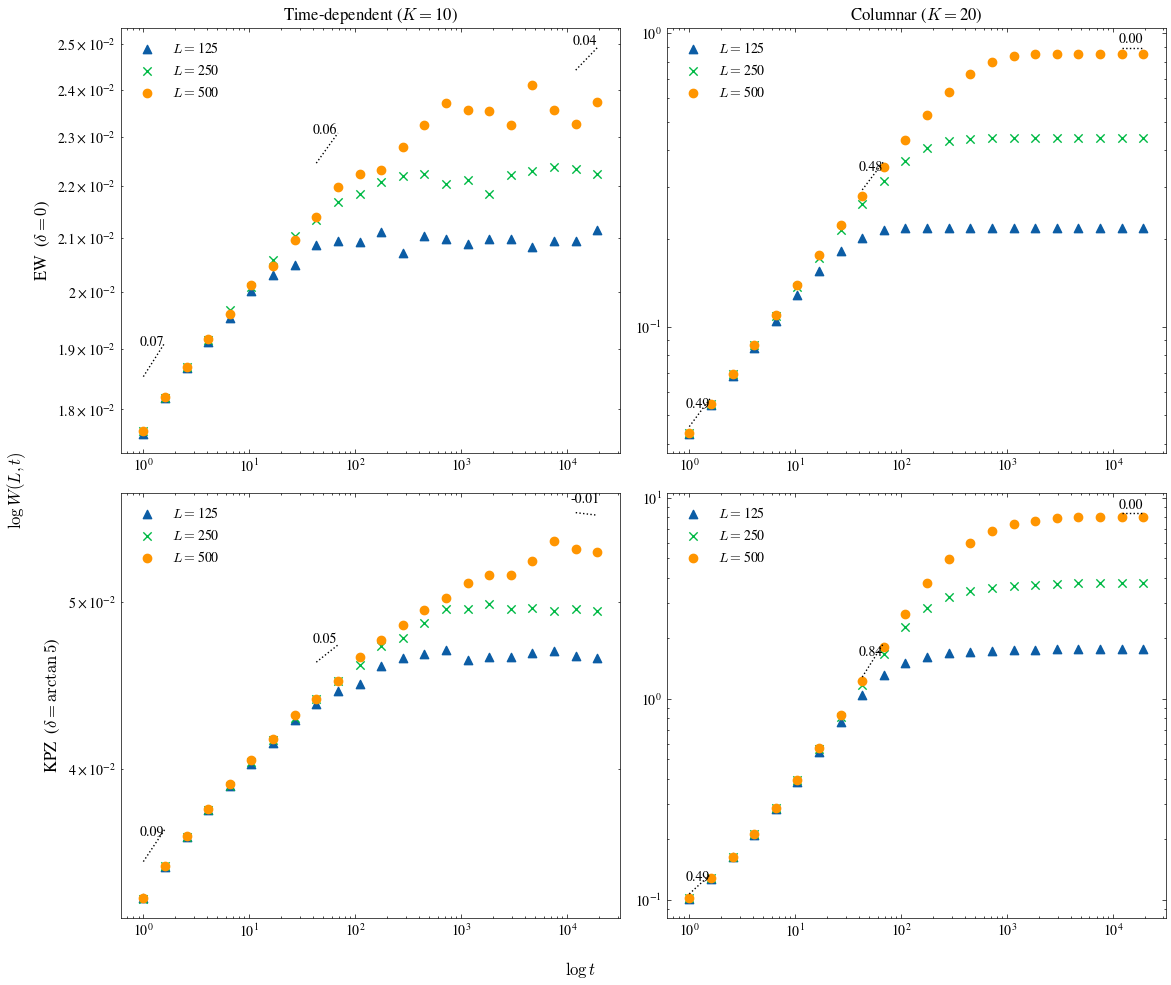

In [10]:
plot_roughness_evolution(avg_df, T, tx, Ks=Ks, ts=ts)

In [11]:
alpha_val = 0.62
z_val = 1.20
beta_val = alpha_val/z_val 
beta_val

0.5166666666666667

- puede que el inicio columnar sea un periodo de relajación para olvidar la condición inicial
- más acople en el columnar (para reducir el ruido y con ello la condición inicial)
- obtener las pendientes de los casos Columnar para calcular sus betas, pasado el inicio.
- reducir el coupling en el dependiente del tiempo porque aquí puede estar pasando de regimen EW a saturación directamente, sin dar tiempo a KPZ. Reducir el coupling $K$ ayuda (porque el acople de KPZ va como $g=\lambda^2 D/\nu^3 \sim 1/K$, alternativamente cambiar la tangente de 5 para ayudar al término KPZ.

In [12]:
print(f"Times: start {(np.round([t[1],t[2]],1))}, medium {np.round([t[9],t[10]],1)}, final {np.round([t[-2],t[-1]],1)}") 
print()

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname, nameeq) in enumerate(zip([0, np.arctan(10)], ["0", "atan10"], ["EW","KPZ"])):

        print("##", nameeq, "( δ =",deltaname,")")
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            # & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
        
            if L == 500:
                print("-- loglog Slopes --")
                slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
                slope_initial /= (np.log(t[2]) - np.log(t[1]))
                slope_medium = np.log(mean_roughness[10]) - np.log(mean_roughness[9])
                slope_medium /= (np.log(t[10]) - np.log(t[9]))
                slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
                slope_final /= (np.log(t[-2]) - np.log(t[-1]))
                print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
                print()
                    

Times: start [1.  1.6], medium [42.9 68.7], final [12089.3 19342.8]

# TimeDep
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.07 0.06 0.04

## KPZ ( δ = atan10 )
# Columnar
## EW ( δ = 0 )
-- loglog Slopes --
β = 0.49 0.48 0.0

## KPZ ( δ = atan10 )


In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12,10))
fig.suptitle("Semilog roughness")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W$")

for i, (typenoise, typelabel) in enumerate(zip(["TimeDep", "Columnar"], ["Time-dependent noise", "Columnar noise"])
):
    print("#", typenoise)
    for j, (delta, deltaname) in enumerate(zip([0, np.arctan(10)], ["0", "atan10"])):

        print("##", deltaname)
        # select rows for this noise type and delta
        mask = mask = (
            (avg_df["typenoise"] == typenoise)
            & (avg_df["deltaname"] == deltaname)
            & (avg_df["T"] == T)
            & ((avg_df["K"] == Ks[0]) | (avg_df["K"] == Ks[1]))
            & (avg_df["L"] < 1000)
        )
        sub_df = avg_df[mask]

        # in case there are multiple (K, L) combos, plot them all
        for _, row in sub_df.iterrows():
            t = row["t"]
            mean_roughness = row["mean_roughness"]
            L = row["L"]
            K = row["K"]
                    
            ax[j,i].scatter(t, mean_roughness**2, label=r"$L=$" + str(L), marker=markerdict[L])

        ax[j,i].set_xscale('log')
        # ax[j,i].set_yscale('log')
        
    # Scalings
    #ax[0,0].semilogx(t[1:-5:], 0.0022 + np.log(t[1:-5:])/2600, linestyle="--", color="k")

ax[0,0].set_title(f"Time-dependent ($K=${Ks[0]})")
ax[0,1].set_title(f"Columnar ($K=${Ks[1]})")      
ax[0,0].set_ylabel(r"EW  ($\delta=0$)", fontsize=12)
ax[1,0].set_ylabel(r"KPZ  ($\delta=\arctan5$)", fontsize=12)

ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()

plt.tight_layout()
# plt.show()

plt.savefig("Figures/Evolution/atan10-sqrtlog1-60.png")

# TimeDep
## 0
## atan10
# Columnar
## 0
## atan10


/tmp/ipykernel_1996441/773748858.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,0].legend()
/tmp/ipykernel_1996441/773748858.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1,1].legend()


In [15]:
z_dict = {"TimeDep": {"EW": 2, "KPZ": 3/2}, "Columnar": {"EW": 2, "KPZ": 1.36}}
alpha_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.07}}
alpha_s_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 3/2, "KPZ": 1.4}}  # anomalous scaling, only for columnar noise
alpha_loc_dict = {"TimeDep": {"EW": 1/2, "KPZ": 1/2}, "Columnar": {"EW": 1, "KPZ": 0.96}} # anomalous scaling, only for columnar noise
beta_dict = {"TimeDep": {"EW": alpha_dict["TimeDep"]["EW"]/z_dict["TimeDep"]["EW"], "KPZ": alpha_dict["TimeDep"]["KPZ"]/z_dict["TimeDep"]["KPZ"]}, 
             "Columnar": {"EW": 0.34, "KPZ": 0.93}}
delta_to_label = {"0": "EW", "atan5": "KPZ"}

#### Family-Vicsek collapse

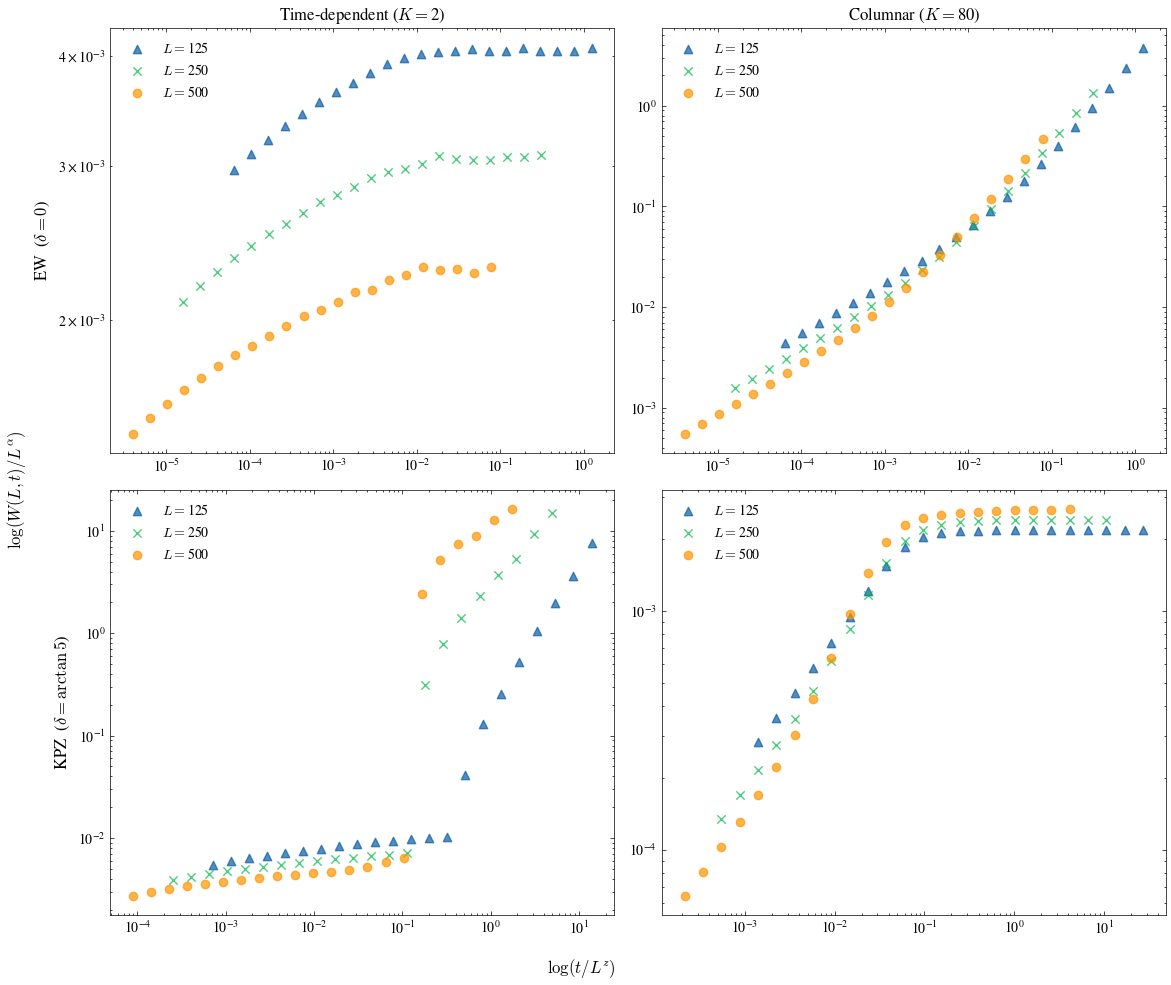

In [28]:
plot_roughness_collapse(avg_df, T, tx, Ks=Ks)

### Small coupling in time dependent, KPZ

Can be observed for $K=1$ and $2$ (with the latter having a more persistent KPZ behavior).

In [37]:
typenoise = "TimeDep"
typelabel = "Time-dependent noise"
deltaname = "atan5"

markerdict = {125: "^", 250: "x", 500: "o", 1000: "s"}

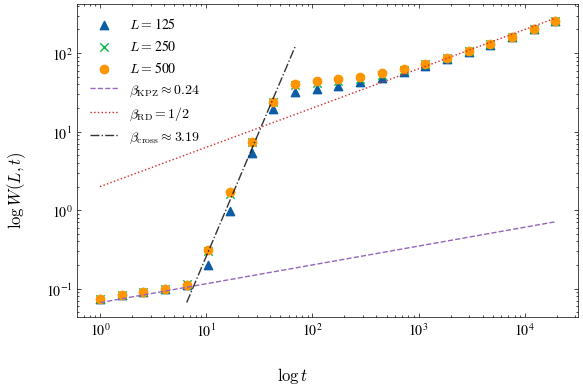

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
# fig.suptitle("Crossover due to small coupling in 2D time-dependent KPZ")

fig.supxlabel(r"$\log t$")
fig.supylabel(r"$\log W(L,t)$")

# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["deltaname"] == deltaname)
    & (avg_df["T"] == T)
    & (avg_df["K"] == 1)
    & (avg_df["L"] < 1000)
)
sub_df = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub_df.iterrows():
    t = row["t"]
    mean_roughness = row["mean_roughness"]
    L = row["L"]
    K = row["K"]                    
    
    ax.scatter(t, mean_roughness, label=r"$L=$" + str(L), marker=markerdict[L])

ax.set_xscale('log')
ax.set_yscale('log')

# Scalings
ax.loglog(t[1:], t[1:]**(0.24) /15, label=r"$\beta_\text{KPZ} \approx 0.24$", linestyle="--", color="tab:purple", alpha=1)
ax.loglog(t[1:], t[1:]**(0.5) * 2, label=r"$\beta_\text{RD} = 1/2$", linestyle=":", color="tab:red", alpha=1)
ax.loglog(t[5:11], t[5:11]**(3.19) /6000, label=r"$\beta_\text{cross} \approx 3.19$", linestyle="dashdot", color="k", alpha=0.8)

ax.legend()

plt.tight_layout()
plt.savefig("Figures/crossover_timedep_K1.png", dpi=300)

In [1]:
0.62/1.2

0.5166666666666667

In [74]:
(t[1],t[2]),(t[7],t[8]),(t[-2],t[-1])

((np.float64(1.00000050000025), np.float64(1.6000008000004002)),
 (np.float64(16.770008385004193), np.float64(26.840013420006713)),
 (np.float64(12089.256044628024), np.float64(19342.819671409838)))

In [75]:
# select rows for this noise type and delta
mask = mask = (
    (avg_df["typenoise"] == typenoise)
    & (avg_df["deltaname"] == deltaname)
    & (avg_df["T"] == T)
    & (avg_df["K"] == 1)
    # & (avg_df["L"] < 1000)
)
sub_df = avg_df[mask]

# in case there are multiple (K, L) combos, plot them all
for _, row in sub_df.iterrows():
    t = row["t"]
    mean_roughness = row["mean_roughness"]
    L = row["L"]
    K = row["K"]

    if L == 500:
        print("#", typenoise)
        print("##", nameeq, "( δ =",deltaname,")")
        print("-- loglog Slopes --")
        slope_initial = np.log(mean_roughness[2]) - np.log(mean_roughness[1])
        slope_initial /= (np.log(t[2]) - np.log(t[1]))
        slope_medium = np.log(mean_roughness[7]) - np.log(mean_roughness[8])
        slope_medium /= (np.log(t[7]) - np.log(t[8]))
        slope_final = np.log(mean_roughness[-2]) - np.log(mean_roughness[-1])
        slope_final /= (np.log(t[-2]) - np.log(t[-1]))
        print("β =",np.round(slope_initial,2), np.round(slope_medium,2), np.round(slope_final,2))
        print()
            

# TimeDep
## KPZ ( δ = atan5 )
-- loglog Slopes --
β = 0.24 3.19 0.48

